# Backtest schedule analytics

Load a `dates.csv`-style schedule (from `scripts/backtest_mvp.py --dates-csv`) and plot **equity**, **cumulative ROI**, **drawdown**, and summary stats.

**Usage:** set `CSV_PATH` in the next cell to your file (e.g. `eval_results/RELIANCE.NS/dates.csv`), then run all cells. Run from repo root or adjust `REPO_ROOT`.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

_cwd = Path.cwd().resolve()
if (_cwd / "tradingagents").is_dir():
    REPO_ROOT = _cwd
elif (_cwd.parent / "tradingagents").is_dir():
    REPO_ROOT = _cwd.parent
else:
    REPO_ROOT = _cwd

# Path to dates.csv (schedule from backtest_mvp --dates-csv)
CSV_PATH = REPO_ROOT / "eval_results" / "RELIANCE.NS" / "dates.csv"

%matplotlib inline
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

In [3]:
def processed_mask(proc: pd.Series) -> pd.Series:
    """Row-wise: True where schedule row counts as processed (matches backtest CSV semantics)."""
    if pd.api.types.is_bool_dtype(proc):
        return proc.fillna(False)
    s = proc.fillna("").astype(str).str.strip().str.lower()
    return s.isin(("1", "true", "yes", "y"))


def load_schedule_csv(path: Path) -> pd.DataFrame:
    """Load dates schedule; keep rows valid for equity / ROI (processed, no error, numeric equity)."""
    df = pd.read_csv(path, encoding="utf-8-sig")
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["equity"] = pd.to_numeric(df["equity"], errors="coerce")
    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    df["cash"] = pd.to_numeric(df["cash"], errors="coerce")
    df["shares"] = pd.to_numeric(df["shares"], errors="coerce")

    err = df["error"].fillna("").astype(str).str.strip()
    # Must be vectorized — is_processed(Series) was wrong (str(Series) is not per-row "true").
    ok = df["equity"].notna() & processed_mask(df["processed"]) & (err == "")
    plot_df = df.loc[ok].sort_values("date").reset_index(drop=True)
    return plot_df


plot_df = load_schedule_csv(CSV_PATH)
if plot_df.empty:
    raise ValueError(f"No valid rows in {CSV_PATH} (need processed=true, empty error, numeric equity)")

initial_equity = float(plot_df["equity"].iloc[0])
plot_df = plot_df.copy()
plot_df["roi_cum"] = plot_df["equity"] / initial_equity - 1.0
plot_df["roi_pct"] = 100.0 * plot_df["roi_cum"]

# Period returns between consecutive valid rows (not necessarily one calendar day)
plot_df["period_return"] = plot_df["equity"].pct_change()

# Drawdown from running peak
peak = plot_df["equity"].cummax()
plot_df["drawdown"] = (plot_df["equity"] - peak) / peak

plot_df.head(10)

,date,processed,final_signal,equity,error,close,cash,shares,roi_cum,roi_pct,period_return,drawdown
0,2024-05-06,True,HOLD,100000.0000,NaN,1409.10,100000.0000,0.000000,0.000000,0.000000,NaN,0.0
1,2024-05-07,True,HOLD,100000.0000,NaN,1391.18,100000.0000,0.000000,0.000000,0.000000,0.000000,0.0
2,2024-05-08,True,SELL,100000.0000,NaN,1408.13,100000.0000,0.000000,0.000000,0.000000,0.000000,0.0
3,2024-05-09,True,SELL,100000.0000,NaN,1383.88,100000.0000,0.000000,0.000000,0.000000,0.000000,0.0
4,2024-05-10,True,BUY,100000.0000,NaN,1397.08,0.0000,71.577862,0.000000,0.000000,0.000000,0.0
5,2024-05-12,True,HOLD,100402.2676,NaN,1402.70,0.0000,71.577862,0.004023,0.402268,0.004023,0.0
6,2024-05-13,True,HOLD,100402.2676,NaN,1402.70,0.0000,71.577862,0.004023,0.402268,0.000000,0.0
7,2024-05-14,True,SELL,101647.7224,NaN,1420.10,101647.7224,0.000000,0.016477,1.647722,0.012405,0.0
8,2024-05-15,True,HOLD,101647.7224,NaN,1416.30,101647.7224,0.000000,0.016477,1.647722,0.000000,0.0
9,2024-05-16,True,BUY,101647.7224,NaN,1425.35,0.0000,71.314219,0.016477,1.647722,0.000000,0.0


In [4]:
final_eq = float(plot_df["equity"].iloc[-1])
total_return = final_eq / initial_equity - 1.0
max_dd = float(plot_df["drawdown"].min())
n = len(plot_df)
retrs = plot_df["period_return"].dropna()
vol = float(retrs.std()) if len(retrs) > 1 else float("nan")
mean_r = float(retrs.mean()) if len(retrs) else float("nan")
# Simple Sharpe on step returns (not annualized; interpret with caution for sparse dates)
sharpe_simple = mean_r / vol if vol and vol > 0 else float("nan")

summary = {
    "initial_equity": initial_equity,
    "final_equity": final_eq,
    "total_return_pct": 100.0 * total_return,
    "max_drawdown_pct": 100.0 * max_dd,
    "n_points": n,
    "period_return_std": vol,
    "period_return_mean": mean_r,
    "sharpe_like_mean_over_std": sharpe_simple,
}
pd.Series(summary).to_frame("value")

,value
initial_equity,100000.000000
final_equity,105616.358339
total_return_pct,5.616358
max_drawdown_pct,-7.481957
n_points,32.000000
period_return_std,0.019215
period_return_mean,0.001946
sharpe_like_mean_over_std,0.101269


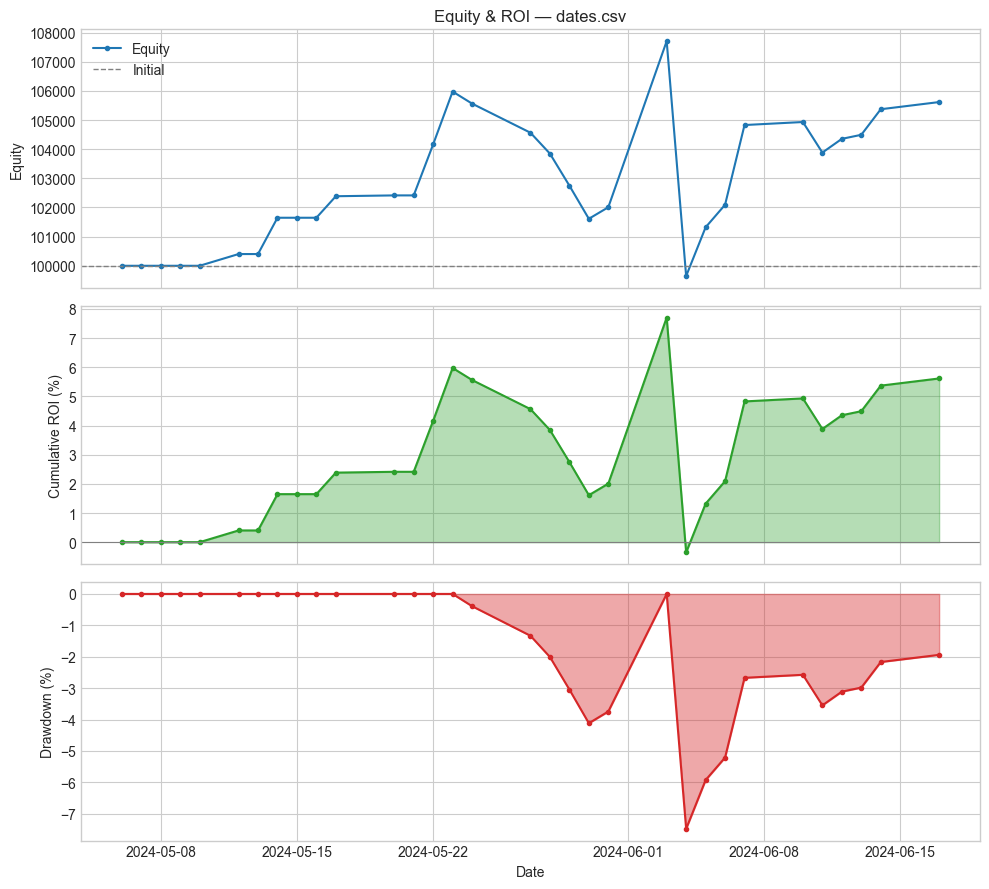

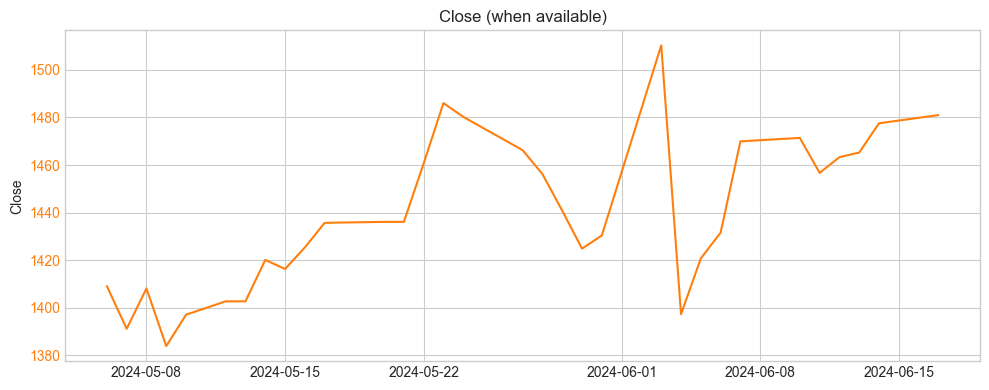

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

dates = plot_df["date"]

axes[0].plot(dates, plot_df["equity"], color="C0", marker="o", markersize=3, label="Equity")
axes[0].axhline(initial_equity, color="gray", linestyle="--", linewidth=1, label="Initial")
axes[0].set_ylabel("Equity")
axes[0].legend(loc="upper left")
axes[0].set_title(f"Equity & ROI — {CSV_PATH.name}")

axes[1].fill_between(dates, 0, 100 * plot_df["roi_cum"], alpha=0.35, color="C2")
axes[1].plot(dates, 100 * plot_df["roi_cum"], color="C2", marker="o", markersize=3)
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_ylabel("Cumulative ROI (%)")

axes[2].fill_between(dates, 100 * plot_df["drawdown"], 0, alpha=0.4, color="C3")
axes[2].plot(dates, 100 * plot_df["drawdown"], color="C3", marker="o", markersize=3)
axes[2].set_ylabel("Drawdown (%)")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()

# Optional: price vs allocation (secondary useful for debugging)
fig2, ax = plt.subplots(figsize=(10, 4))
if plot_df["close"].notna().any():
    ax.plot(dates, plot_df["close"], color="C1", label="Close")
    ax.set_ylabel("Close")
    ax.set_title("Close (when available)")
    ax.tick_params(axis="y", labelcolor="C1")
plt.tight_layout()
plt.show()